In [1]:

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns


In [6]:

dataset_path = "/kaggle/input/datasets/upalbackup30/cnn-model"

train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print(train_path)
print(test_path)


/kaggle/input/datasets/upalbackup30/cnn-model/train
/kaggle/input/datasets/upalbackup30/cnn-model/test


In [7]:

image_size = (224,224)
batch_size = 32

train_data = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

val_data = keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary"
)

test_data = keras.utils.image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

class_names = train_data.class_names
print(class_names)


Found 5216 files belonging to 2 classes.
Using 4173 files for training.


I0000 00:00:1788796174.642899      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


In [8]:

AUTOTUNE = tf.data.AUTOTUNE

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

preprocess = keras.applications.mobilenet_v2.preprocess_input

train_data = train_data.map(
    lambda x,y:(preprocess(augmentation(x)),y)
)

val_data = val_data.map(
    lambda x,y:(preprocess(x),y)
)

test_data = test_data.map(
    lambda x,y:(preprocess(x),y)
)

train_data = train_data.prefetch(AUTOTUNE)
val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)


In [9]:

base_model = keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = keras.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.3
    ),
    keras.callbacks.ModelCheckpoint(
        "best_pneumonia_model.keras",
        save_best_only=True
    )
]


In [13]:

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10


I0000 00:00:1788796219.702275     133 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 80s 510ms/step - accuracy: 0.8284 - loss: 0.3802 - val_accuracy: 0.9252 - val_loss: 0.2106 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 0.9257 - loss: 0.2005 - val_accuracy: 0.9300 - val_loss: 0.1807 - learning_rate: 1.0000e-04
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 374ms/step - accuracy: 0.9406 - loss: 0.1636 - val_accuracy: 0.9453 - val_loss: 0.1522 - learning_rate: 1.0000e-04
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 374ms/step - accuracy: 0.9442 - loss: 0.1499 - val_accuracy: 0.9521 - val_loss: 0.1431 - learning_rate: 1.0000e-04
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 0.9540 - loss: 0.1303 - val_accuracy: 0.9569 - val_loss: 0.1332 - learning_rate: 1.0000e-04
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 367ms/step - accuracy: 0.9581 - loss: 0.1198 - val_accuracy: 0.9559 - val_loss: 0.1357 - learning_rate: 1.0000e-04
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 371ms/step - 

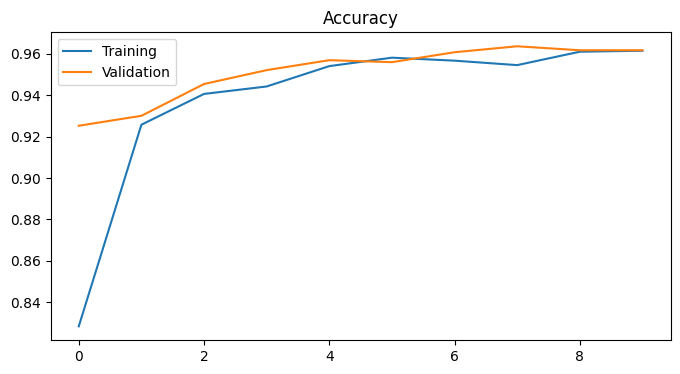

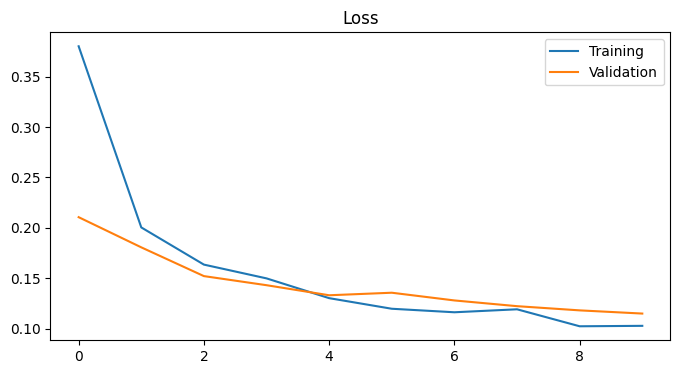

In [14]:

plt.figure(figsize=(8,4))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Training","Validation"])
plt.title("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Training","Validation"])
plt.title("Loss")
plt.show()


In [15]:

loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

predictions = model.predict(test_data)
predicted_labels = (predictions > 0.5).astype(int).flatten()

true_labels = np.concatenate(
    [y.numpy() for x,y in test_data]
)

print(classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names
))


20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - accuracy: 0.8077 - loss: 0.5222
Test Accuracy: 0.807692289352417
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 251ms/step
              precision    recall  f1-score   support

      NORMAL       0.97      0.50      0.66       234
   PNEUMONIA       0.77      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.75      0.76       624
weighted avg       0.84      0.81      0.79       624



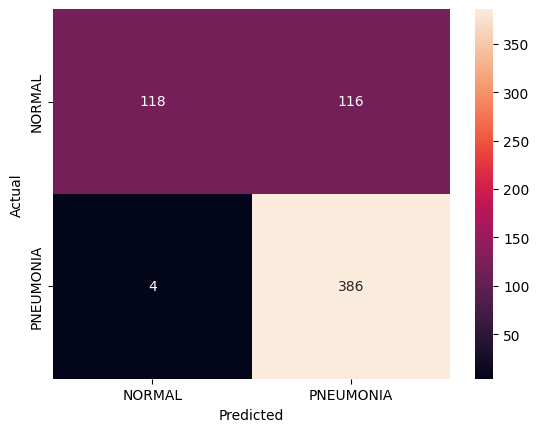

In [17]:

cm = confusion_matrix(true_labels, predicted_labels)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [18]:

model.save("pneumonia_mobilenetv2_model.keras")
print("Model saved successfully")


Model saved successfully
